In [1]:
import os
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, pipeline
)
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device} | Seed: {SEED}")

Device: cuda | Seed: 42


In [2]:
raw_dataset = load_dataset("emotion")
class_names = raw_dataset["train"].features["label"].names

print(f"Split: {list(raw_dataset.keys())}")
print(f"Train: {len(raw_dataset['train'])}")
print(f"Validation: {len(raw_dataset['validation'])}")
print(f"Test: {len(raw_dataset['test'])}")
print(f"Классы: {class_names}")

print("\nПримеры из train:")
for i in range(3):
    idx = random.randint(0, len(raw_dataset["train"]) - 1)
    print(f"[{class_names[raw_dataset['train'][idx]['label']]}] {raw_dataset['train'][idx]['text']}")

print("\nЗадача: классификация коротких английских предложений по 6 базовым эмоциям.")

README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Split: ['train', 'validation', 'test']
Train: 16000
Validation: 2000
Test: 2000
Классы: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

Примеры из train:
[sadness] i do find new friends i m going to try extra hard to make them stay and if i decide that i don t want to feel hurt again and just ride out the last year of school on my own i m going to have to try extra hard not to care what people think of me being a loner
[joy] i asked them to join me in creating a world where all year old girls could grow up feeling hopeful and powerful
[love] i feel when you are a caring person you attract other caring people into your life

Задача: классификация коротких английских предложений по 6 базовым эмоциям.


In [3]:
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

sample_texts = [
    "i feel completely devastated after the bad news",
    "so excited for the weekend trip!",
    "i just feel really neutral about it"
]

print("Разбор токенизации на примерах:\n")
for i, txt in enumerate(sample_texts):
    encoded = tokenizer(txt, add_special_tokens=True)
    tokens = tokenizer.convert_ids_to_tokens(encoded['input_ids'])
    print(f"Пример {i+1}:")
    print(f"Text      : {txt}")
    print(f"Tokens    : {tokens}")
    print(f"Input IDs : {encoded['input_ids']}")
    print(f"Attn Mask : {encoded['attention_mask']}")
    print(f"Special   : {tokens[0]} (CLS), {tokens[-1]} (SEP)\n")

batch = tokenizer(sample_texts, padding="max_length", truncation=True, max_length=12, return_tensors="pt")
print("Padding/Truncation Demo (max_length=12):")
for i in range(len(sample_texts)):
    ids = batch['input_ids'][i].tolist()
    print(f"ID {i}: {ids} (len={len(ids)})")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Разбор токенизации на примерах:

Пример 1:
Text      : i feel completely devastated after the bad news
Tokens    : ['[CLS]', 'i', 'feel', 'completely', 'devastated', 'after', 'the', 'bad', 'news', '[SEP]']
Input IDs : [101, 1045, 2514, 3294, 13879, 2044, 1996, 2919, 2739, 102]
Attn Mask : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Special   : [CLS] (CLS), [SEP] (SEP)

Пример 2:
Text      : so excited for the weekend trip!
Tokens    : ['[CLS]', 'so', 'excited', 'for', 'the', 'weekend', 'trip', '!', '[SEP]']
Input IDs : [101, 2061, 7568, 2005, 1996, 5353, 4440, 999, 102]
Attn Mask : [1, 1, 1, 1, 1, 1, 1, 1, 1]
Special   : [CLS] (CLS), [SEP] (SEP)

Пример 3:
Text      : i just feel really neutral about it
Tokens    : ['[CLS]', 'i', 'just', 'feel', 'really', 'neutral', 'about', 'it', '[SEP]']
Input IDs : [101, 1045, 2074, 2514, 2428, 8699, 2055, 2009, 102]
Attn Mask : [1, 1, 1, 1, 1, 1, 1, 1, 1]
Special   : [CLS] (CLS), [SEP] (SEP)

Padding/Truncation Demo (max_length=12):
ID 0: [101, 1045, 2514, 3294

In [4]:
pretrained_pipe = pipeline(
    "text-classification",
    model="cardiffnlp/twitter-roberta-base-sentiment",
    tokenizer="cardiffnlp/twitter-roberta-base-sentiment"
)

print(" нференс готовой pretrained модели:\n")
for txt in sample_texts:
    res = pretrained_pipe(txt)[0]
    print(f"Text: '{txt}'\n  -> Label: {res['label']} | Score: {res['score']:.3f}\n")

print(" Вывод: Готовая модель решает задачу общего сентимента (positive/negative/neutral), "
      "тогда как наша задача требует различения 6 специфичных эмоций. Результаты будут приблизительными, "
      "что подтверждает необходимость fine-tuning.")

config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

 нференс готовой pretrained модели:

Text: 'i feel completely devastated after the bad news'
  -> Label: LABEL_0 | Score: 0.967

Text: 'so excited for the weekend trip!'
  -> Label: LABEL_2 | Score: 0.991

Text: 'i just feel really neutral about it'
  -> Label: LABEL_1 | Score: 0.671

 ывод: Готовая модель решает задачу общего сентимента (positive/negative/neutral), тогда как наша задача требует различения 6 специфичных эмоций. Результаты будут приблизительными, что подтверждает необходимость fine-tuning.


In [5]:
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

tokenized = raw_dataset.map(tokenize_function, batched=True, remove_columns=["text"])
tokenized = tokenized.rename_column("label", "labels")
tokenized.set_format("torch")

train_ds = tokenized["train"]
val_ds = tokenized["validation"]
test_ds = tokenized["test"]

num_labels = len(class_names)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro")
    }

os.makedirs("artifacts", exist_ok=True)

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    seed=SEED,
    logging_steps=50,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

print("Запуск fine-tuning...")
train_output = trainer.train()
print("Обучение завершено.")

best_val_f1 = trainer.state.best_metric
print(f"Лучший F1 Macro на Validation: {best_val_f1:.4f}")

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Обучение завершено.
Лучший F1 Macro на Validation: 0.9109



Финальная оценка на test-выборке...


Test Accuracy : 0.9325
Test F1 Macro : 0.8914


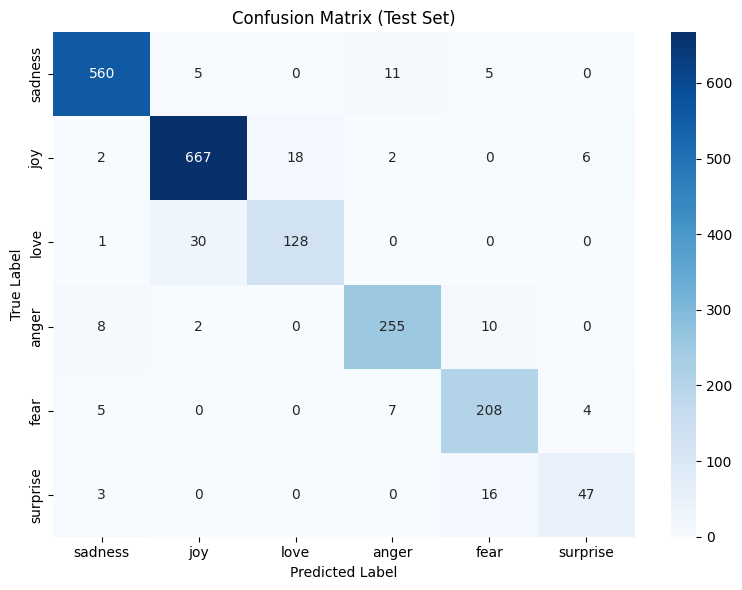


Найдено ошибок в выборке: 5

Примеры ошибок модели:
Text   : i could feel his breath on me and smell the sweet scent of him...
True   : joy | Pred: love | Conf: 0.903

Text   : at a party i met a girl who drew me to her...
True   : anger | Pred: fear | Conf: 0.587

Text   : i feel this strange sort of liberation...
True   : surprise | Pred: fear | Conf: 0.684

Text   : i feel blessed beyond blessed to share my life with you each week...
True   : love | Pred: joy | Conf: 0.556

Text   : i hope everyone can help with charity work without feeling stressed about such things...
True   : sadness | Pred: anger | Conf: 0.542



In [6]:
print("\nФинальная оценка на test-выборке...")
test_metrics = trainer.evaluate(eval_dataset=test_ds)
test_acc = test_metrics["eval_accuracy"]
test_f1 = test_metrics["eval_f1_macro"]
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test F1 Macro : {test_f1:.4f}")

preds = trainer.predict(test_ds)
y_true = preds.label_ids
y_pred = preds.predictions.argmax(-1)
y_conf = torch.nn.functional.softmax(torch.tensor(preds.predictions), dim=1).max(dim=1).values.numpy()

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix (Test Set)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("artifacts/confusion_matrix.png", dpi=150)
plt.show()

np.random.seed(SEED)
n_samples = 50
idxs = np.random.choice(len(y_true), n_samples, replace=False)
df_pred = pd.DataFrame({
    "text": [raw_dataset["test"][i]["text"] for i in idxs],
    "true_label": [class_names[y_true[i]] for i in idxs],
    "pred_label": [class_names[y_pred[i]] for i in idxs],
    "confidence": [float(y_conf[i]) for i in idxs]
})
df_pred.to_csv("artifacts/sample_predictions.csv", index=False, encoding="utf-8")

errors_df = df_pred[df_pred["true_label"] != df_pred["pred_label"]]
print(f"\nНайдено ошибок в выборке: {len(errors_df)}")
print("\nПримеры ошибок модели:")
for _, row in errors_df.head(7).iterrows():
    print(f"Text   : {row['text'][:90]}...")
    print(f"True   : {row['true_label']} | Pred: {row['pred_label']} | Conf: {row['confidence']:.3f}\n")